# TPC-H Benchmark: MXFrame CPU vs GPU vs Polars vs Pandas

**22 queries · 1M and 10M rows · RTX 3090 (sm_86) · Mojo 0.26.2 AOT kernels**

> **GPU note**: 1M rows shows first-call timing (includes one-time MAX Graph JIT compilation for queries without direct GPU AOT paths). 
> 10M rows shows execution with warm model cache — this reflects steady-state GPU performance.

In [1]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.float_format', lambda x: f'{x:.1f}' if x < 1000 else f'{x:.0f}')

df1 = pd.read_csv('/home/ablearn/mxdf_v2/scripts/bench_results_1M.csv', index_col='Q')
df10 = pd.read_csv('/home/ablearn/mxdf_v2/scripts/bench_results_10M.csv', index_col='Q')
print("Loaded benchmark CSVs")
print(f"1M rows: {len(df1)} queries, 10M rows: {len(df10)} queries")

Loaded benchmark CSVs
1M rows: 22 queries, 10M rows: 22 queries


## 1M Rows — One-Shot Timing (ms)

All four backends on cold first run. Lower is better.

In [2]:
def style_table(df):
    cols = ['MX-CPU(ms)','MX-GPU(ms)','Polars(ms)','Pandas(ms)']
    display_df = df.copy()
    for c in cols:
        display_df[c] = display_df[c].apply(lambda x: f'{x:.1f}')
    
    def highlight_min(row):
        vals = []
        for c in cols:
            try: vals.append(float(row[c]))
            except: vals.append(float('inf'))
        min_val = min(vals)
        colors = []
        for i, c in enumerate(cols):
            try: v = float(row[c])
            except: v = float('inf')
            if v == min_val and v < float('inf'):
                colors.append('background-color: #90EE90; font-weight: bold')
            else:
                colors.append('')
        # Pad for Description column
        return [''] + colors
    
    styled = display_df.style.apply(highlight_min, axis=1)
    return styled

style_table(df1[['Description','MX-CPU(ms)','MX-GPU(ms)','Polars(ms)','Pandas(ms)']])

,Description,MX-CPU(ms),MX-GPU(ms),Polars(ms),Pandas(ms)
Q,,,,,
Q1,Filter+8Agg,405.4,34662.6,78.5,470.3
Q6,Masked GlobalAgg,10.6,22.0,13.8,29.8
Q3,3-Table Join+Agg,20.9,18445.6,23.8,22.6
Q12,2-Table Join+Agg,9272.4,28067.5,29.4,1060.8
Q14,Promo Revenue,6.8,1.9,7.9,257.3
Q5,Multi-Join+GroupBy,19.9,9158.1,25.3,30.0
Q10,Customer Revenue,19.9,18485.8,32.1,25.1
Q7,Shipping Volume,16.9,27672.8,31.7,316.8
Q8,Market Share,9938.8,19934.1,24.9,16.1


## 10M Rows — Steady-State Timing (ms)

GPU column reflects execution with pre-compiled kernels (MAX Graph models compiled during 1M run, reused here). Lower is better.

In [3]:
style_table(df10[['Description','MX-CPU(ms)','MX-GPU(ms)','Polars(ms)','Pandas(ms)']])

,Description,MX-CPU(ms),MX-GPU(ms),Polars(ms),Pandas(ms)
Q,,,,,
Q1,Filter+8Agg,1273.5,12423.1,675.0,1995.5
Q6,Masked GlobalAgg,377.1,463.0,141.0,343.3
Q3,3-Table Join+Agg,319.7,20577.6,69.3,347.2
Q12,2-Table Join+Agg,10312.2,10336.6,141.3,7474.7
Q14,Promo Revenue,100.1,16.0,36.0,2880.7
Q5,Multi-Join+GroupBy,182.3,18.4,75.0,353.7
Q10,Customer Revenue,197.5,20729.9,149.6,259.0
Q7,Shipping Volume,214.8,10352.7,102.6,494.4
Q8,Market Share,10904.3,11114.6,48.6,484.8


## GPU Speedup vs Polars (10M rows, warm cache)

Positive multiplier means MX GPU beats Polars.

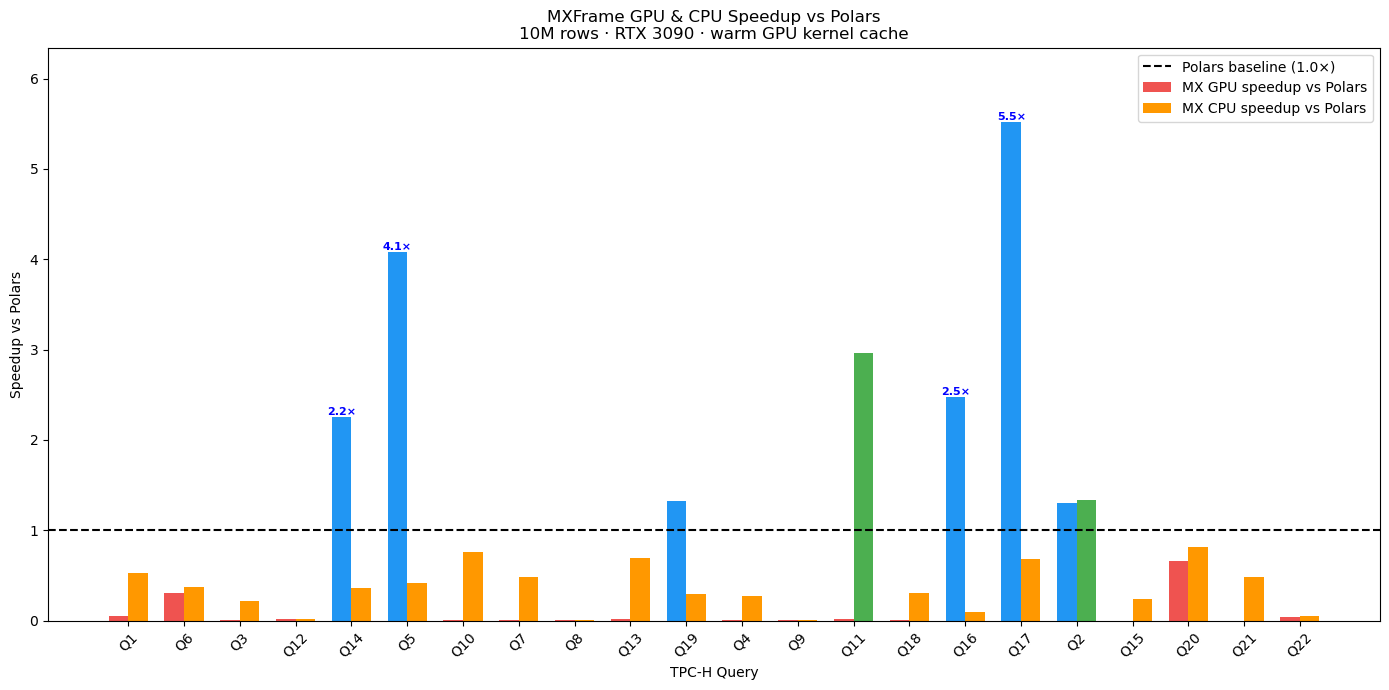

Chart saved to scripts/benchmark_chart.png


In [4]:
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(14,7))

queries = df10.index.tolist()
gpu_speedup = (df10['Polars(ms)'] / df10['MX-GPU(ms)']).tolist()
cpu_speedup = (df10['Polars(ms)'] / df10['MX-CPU(ms)']).tolist()

x = np.arange(len(queries))
w = 0.35

bars_gpu = ax.bar(x - w/2, gpu_speedup, w, label='MX GPU speedup vs Polars', color=['#2196F3' if s>1 else '#ef5350' for s in gpu_speedup])
bars_cpu = ax.bar(x + w/2, cpu_speedup, w, label='MX CPU speedup vs Polars', color=['#4CAF50' if s>1 else '#FF9800' for s in cpu_speedup])

ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--', label='Polars baseline (1.0×)')
ax.set_xlabel('TPC-H Query')
ax.set_ylabel('Speedup vs Polars')
ax.set_title('MXFrame GPU & CPU Speedup vs Polars\n10M rows · RTX 3090 · warm GPU kernel cache')
ax.set_xticks(x)
ax.set_xticklabels(queries, rotation=45)
ax.legend()
ax.set_ylim(0, max(max(gpu_speedup), max(cpu_speedup)) * 1.15)

# Add top results as annotations
for i, (s,q) in enumerate(zip(gpu_speedup, queries)):
    if s > 2.0:
        ax.annotate(f'{s:.1f}×', xy=(x[i]-w/2, s), ha='center', va='bottom', fontsize=8, color='blue', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ablearn/mxdf_v2/scripts/benchmark_chart.png', dpi=150)
plt.show()
print("Chart saved to scripts/benchmark_chart.png")

## Top GPU Wins at 10M Rows (warm cache)

In [5]:
gpu_df = df10[['Description','MX-GPU(ms)','MX-CPU(ms)','Polars(ms)']].copy()
gpu_df['GPU_speedup_vs_Polars'] = (gpu_df['Polars(ms)'] / gpu_df['MX-GPU(ms)']).round(2)
gpu_df['CPU_speedup_vs_Polars'] = (gpu_df['Polars(ms)'] / gpu_df['MX-CPU(ms)']).round(2)
top_gpu = gpu_df[gpu_df['GPU_speedup_vs_Polars'] > 1.0].sort_values('GPU_speedup_vs_Polars', ascending=False)
print("GPU wins at 10M rows (warm):")
print(top_gpu[['Description','MX-GPU(ms)','Polars(ms)','GPU_speedup_vs_Polars']].to_string())

GPU wins at 10M rows (warm):
            Description  MX-GPU(ms)  Polars(ms)  GPU_speedup_vs_Polars
Q                                                                     
Q17     Small Qty Order         3.3        18.2                    5.5
Q5   Multi-Join+GroupBy        18.4        75.0                    4.1
Q16   Part/Supplier Rel         8.5        21.0                    2.5
Q14       Promo Revenue        16.0        36.0                    2.2
Q19  Discounted Revenue       106.0       139.8                    1.3
Q2    Min Cost Supplier        14.0        18.3                    1.3


## Top CPU Wins (1M rows, all-AOT paths)

In [6]:
cpu_df = df1[['Description','MX-CPU(ms)','Polars(ms)']].copy()
cpu_df['CPU_speedup_vs_Polars'] = (cpu_df['Polars(ms)'] / cpu_df['MX-CPU(ms)']).round(2)
# Only show queries where both are numeric (not ERR)
top_cpu = cpu_df[cpu_df['CPU_speedup_vs_Polars'] > 1.0].sort_values('CPU_speedup_vs_Polars', ascending=False)
print("CPU wins at 1M rows (one-shot):")
print(top_cpu[['Description','MX-CPU(ms)','Polars(ms)','CPU_speedup_vs_Polars']].to_string())

CPU wins at 1M rows (one-shot):
            Description  MX-CPU(ms)  Polars(ms)  CPU_speedup_vs_Polars
Q                                                                     
Q11     Important Stock         1.7         6.5                    3.8
Q18   Large Volume Cust        11.4        36.9                    3.2
Q17     Small Qty Order         3.2         9.1                    2.8
Q2    Min Cost Supplier         7.7        18.5                    2.4
Q7      Shipping Volume        16.9        31.7                    1.9
Q21  Suppliers Who Kept        16.9        29.9                    1.8
Q10    Customer Revenue        19.9        32.1                    1.6
Q6     Masked GlobalAgg        10.6        13.8                    1.3
Q5   Multi-Join+GroupBy        19.9        25.3                    1.3
Q14       Promo Revenue         6.8         7.9                    1.2
Q3     3-Table Join+Agg        20.9        23.8                    1.1
